In [31]:
!pip install open_clip_torch==2.23.0 transformers==4.35.2 matplotlib ftfy regex tqdm 
!pip install chromadb 

In [32]:
import os, json
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import torch
import chromadb
from chromadb.config import Settings
import matplotlib.pyplot as lib
import open_clip

In [33]:
TEST_FOLDER = "/kaggle/input/datasets/memadf/notebook-test"

image_paths = [
    os.path.join(TEST_FOLDER, f)
    for f in os.listdir(TEST_FOLDER)
    if f.lower().endswith((".jpg", ".png", ".jpeg"))
]

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"

medclip_model, _ , medclip_preprocess = open_clip.create_model_and_transforms('hf-hub:luhuitong/CLIP-ViT-L-14-448px-MedICaT-ROCO')
medclip_tokenizer = open_clip.get_tokenizer('hf-hub:luhuitong/CLIP-ViT-L-14-448px-MedICaT-ROCO')
medclip_model = medclip_model.to(device)
medclip_model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1024,), eps=1e-05, elementwi

In [41]:
def encode_image(path):
    image = medclip_preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = medclip_model.encode_image(image)
        emb = torch.nn.functional.normalize(emb, dim=-1)

    return emb.cpu().numpy()[0]


def encode_text(query):
    with torch.no_grad():
        tokens = medclip_tokenizer([query]).to(device)
        emb = medclip_model.encode_text(tokens)
        emb = torch.nn.functional.normalize(emb, dim=-1)
    return emb.cpu().numpy()[0]


In [46]:
img_emb = []
valid_paths = []

for path in tqdm(image_paths, desc="Encoding images"):
    try:
        emb = encode_image(path)
        img_emb.append(emb)
        valid_paths.append(path)
    except:
        continue

Encoding images:   0%|          | 0/10 [00:00<?, ?it/s]

In [48]:
client = chromadb.Client(Settings(anonymized_telemetry=False))

collection = client.get_or_create_collection(
    name=f"{MODE}_collection",
    metadata={"hnsw:space": "cosine"}
)

try:
    collection.delete(where={})
except:
    pass


collection.add(
    embeddings=[e.tolist() for e in img_emb],
    documents=["image"] * len(img_emb),
    metadatas=[{"image_path": p} for p in valid_paths],
    ids=[f"{MODE}_{i}" for i in range(len(img_emb))]
)

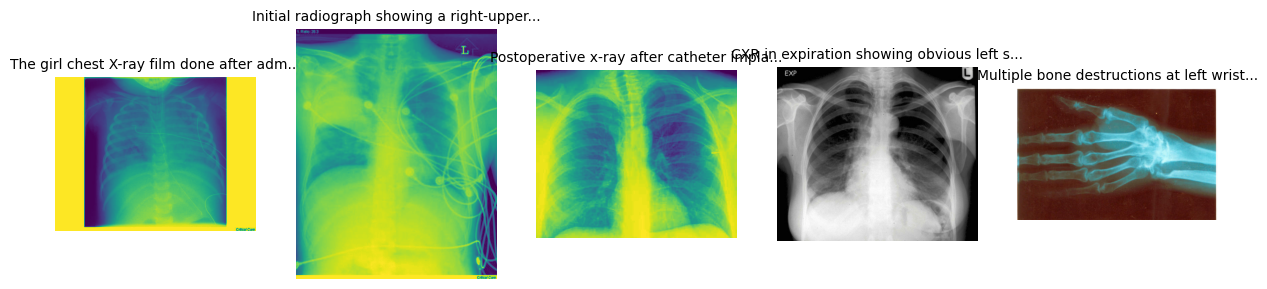

In [49]:
query = "chest X-ray of a girl"
query_emb = encode_text(query)

res = collection.query(query_embeddings=[query_emb], n_results=5)

plt.figure(figsize=(15, 5))

for i, meta in enumerate(res["metadatas"][0]):
    img = Image.open(meta["image_path"])
    caption = res["documents"][0][i]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(caption[:40] + "...", fontsize=10)

plt.show()